In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
housing = fetch_california_housing(as_frame = True)
housing_df = housing.frame
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: >

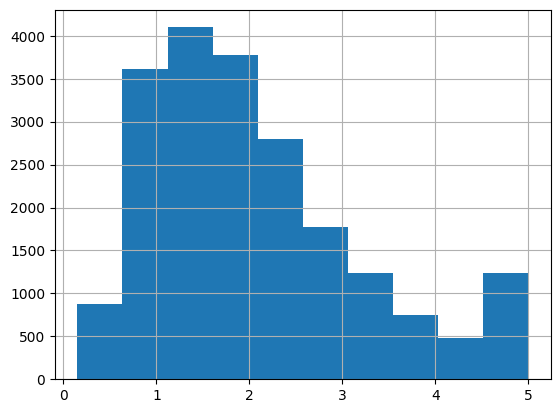

In [6]:
housing_df['MedHouseVal'].hist()

In [7]:
housing_df = housing_df[housing_df['MedHouseVal'] < 5]

In [8]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000
mean,3.676411,28.373066,5.361708,1.096621,1441.368485,3.096560,35.651872,-119.562378,1.920553
std,1.570602,12.504050,2.293321,0.452136,1144.075196,10.639195,2.150066,2.005760,0.971109
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.526300,18.000000,4.416667,1.005882,796.000000,2.446614,33.930000,-121.760000,1.164750
50%,3.449050,28.000000,5.185730,1.048576,1179.000000,2.837779,34.270000,-118.500000,1.736000
75%,4.582500,37.000000,5.971083,1.099222,1746.250000,3.306021,37.730000,-117.990000,2.479000
max,15.000100,52.000000,132.533333,34.066667,35682.000000,1243.333333,41.950000,-114.310000,4.991000


In [9]:
X = housing_df.drop('MedHouseVal', axis=1)
y = housing_df['MedHouseVal']

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
len(model.coef_)

8

In [15]:
y_pred = model.predict(X_test)

In [16]:
print("Прогнози (Predictions):")
print(y_pred[:5])

print("\nРеальні ціни (Actual):")
print(y_test[:5])

Прогнози (Predictions):
[2.77716494 2.64363229 2.77467155 1.68173394 2.56140831]

Реальні ціни (Actual):
8979     3.298
17945    2.947
17356    1.957
3378     1.615
15797    2.750
Name: MedHouseVal, dtype: float64


In [17]:
from sklearn.metrics import mean_squared_error

In [18]:
mse = mean_squared_error(y_test, y_pred)
print(f"\nMean Squared Error: {mse}")


Mean Squared Error: 0.4132737244622423


In [19]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 0.6428636904214161


In [20]:
from sklearn.metrics import r2_score

In [22]:
score = r2_score(y_test, y_pred)
print(f"R2 score: {score * 100:.2f}%")

R2 score: 56.89%


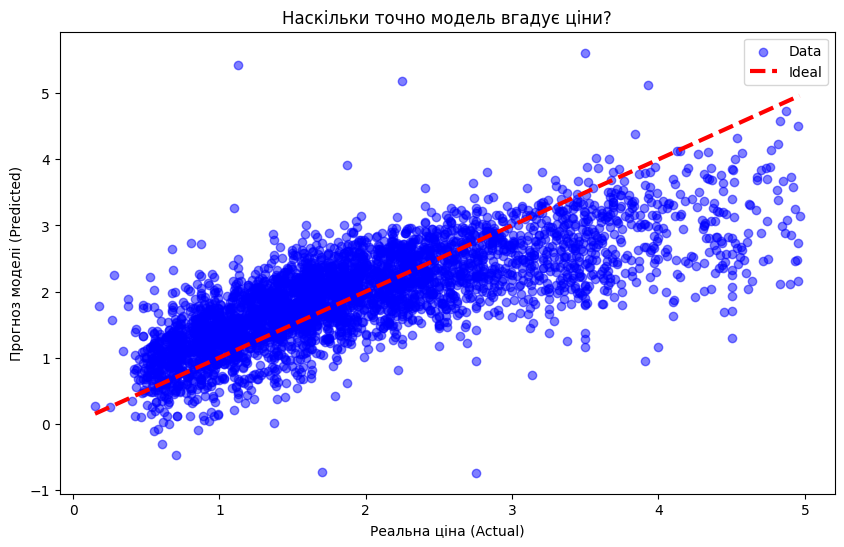

In [25]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha = 0.5, color = 'blue', label = 'Data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Ideal')

plt.xlabel('Реальна ціна (Actual)')
plt.ylabel('Прогноз моделі (Predicted)')
plt.title('Наскільки точно модель вгадує ціни?')
plt.legend()
plt.show()